<a href="https://colab.research.google.com/github/RCutrino/cmapss_project/blob/main/notebook/02_preprocessing_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMAPSS FD001 — Preprocessing & Feature Engineering

## Objectives

- remove low-information sensors
- normalize sensor measurements
- create rolling statistics
- generate lag-based temporal features
- prepare dataset for predictive modeling

## Environment and Library Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import os

import joblib
import sys
sys.path.append("..")
from src.preprocessing import get_low_variance_sensors, get_top_correlated_sensors, normalize_sensors, add_rolling_stats, add_lag_features, build_final_dataset, split_datasets

## Load data

In [6]:
df = pd.read_parquet("../data/interim/train_fd001_eda.parquet")
df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL,life_phase
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191,early
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190,early
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189,early
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188,early
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187,early


## Sensors selection

We apply a two-stage selection strategy:
1. **Low-variance filtering**: sensors whose variance falls below a threshold (1e-2) are considered near-constant and dropped — they cannot encode degradation trends.
2. **Correlation-based selection**: among the remaining sensors, we retain the top-N most correlated (in absolute value) with the Remaining Useful Life (RUL) target.

> **Threshold rationale**: `1e-2` was chosen empirically on FD001.

In [7]:
low_variance_sensors = get_low_variance_sensors(df)
df = df.drop(columns=low_variance_sensors)

In [8]:
print(f"Removed {len(low_variance_sensors)} sensors")
print(low_variance_sensors)

Removed 10 sensors
['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'sensor_6', 'sensor_15', 'sensor_8', 'sensor_13']


Sensors with near-zero variance were automatically identified
and removed from the dataset.

These sensors are unlikely to contribute meaningful predictive information

In [9]:
selected_sensors = get_top_correlated_sensors(df, "RUL", top_n=5)
selected_sensors

['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_21']

Top sensors are automatically selected based on absolute correlation with RUL.

## Sensor normalization

Sensor measurements span very different physical scales (e.g., temperatures in hundreds of °C vs. pressures in single digits).\  
Without normalization, distance-based models and gradient-based optimizers are dominated by high-magnitude features.

We apply **Z-score standardization** (zero mean, unit variance) via `StandardScaler`.

> **Normalization strategy**: in this notebook the scaler is fitted on the full
training set to produce a globally normalized dataset for exploratory purposes.\
In the modeling notebooks, normalization will be re-applied fitting the scaler
exclusively on the training fold to prevent data leakage during model evaluation.

In [12]:
df, scaler = normalize_sensors(df)
joblib.dump(scaler, '../outputs/scaler.pkl')

['../outputs/scaler.pkl']

In [13]:
round(df[[col for col in df.columns if "sensor" in col]].describe().loc[["mean", "std"]], 2)

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_14,sensor_17,sensor_20,sensor_21
mean,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Sensor values are now centered and scaled.

Standardization improves:
- numerical stability
- feature comparability
- downstream model performance

## Rolling window features

Sensor signals in turbofan engines are noisy due to measurement noise and short-term operational fluctuations.

Rolling statistics help by:
- **Rolling mean**: smooths the signal, making gradual degradation trends more visible.
- **Rolling std**: captures local volatility, which can increase as components degrade.

We use a window of **5 cycles**, computed per engine (`groupby "engine_id")`) to avoid mixing signals across different units.

> The first `window_size - 1` rows per engine will produce NaN values and will need to be handled downstream (e.g., via `dropna()` or forward-fill).

In [14]:
df = add_rolling_stats(df, sensor_cols=selected_sensors, window_size=5)

In [15]:
df.filter(regex="rolling").head()

,sensor_11_rolling_mean,sensor_11_rolling_std,sensor_4_rolling_mean,sensor_4_rolling_std,sensor_12_rolling_mean,sensor_12_rolling_std,sensor_7_rolling_mean,sensor_7_rolling_std,sensor_21_rolling_mean,sensor_21_rolling_std
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.798141,0.565607,-0.636393,0.239927,1.177611,0.586512,0.899689,0.323403,0.954423,0.309459


In [16]:
engine = 1
subset = df[df["engine_id"] == engine]

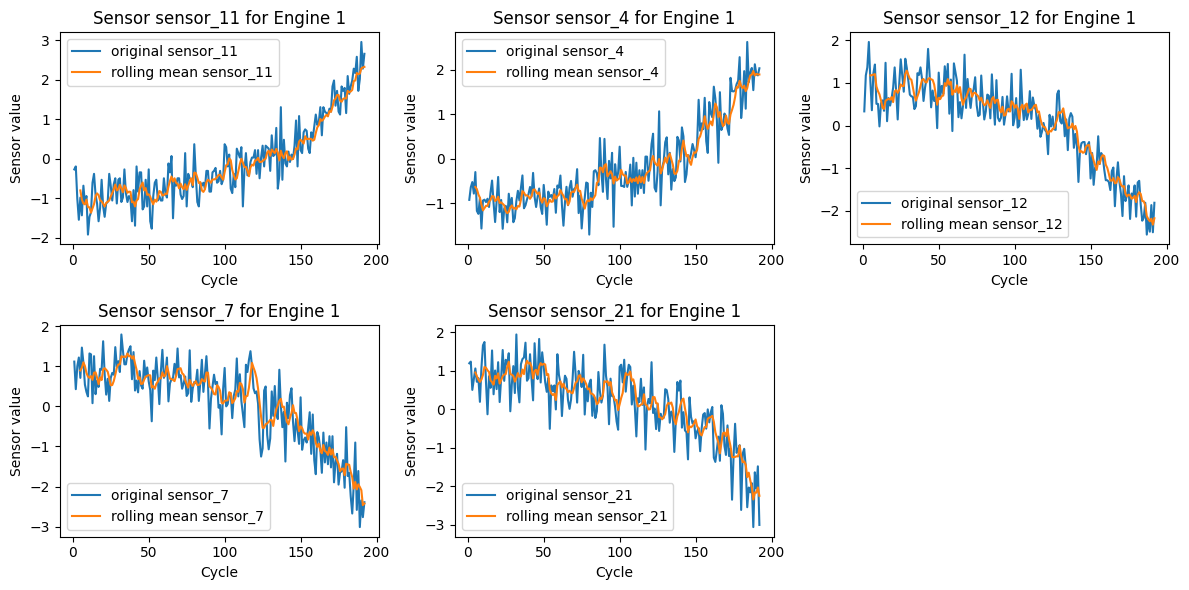

In [17]:
num_sensors = len(selected_sensors)
# Determine a suitable grid size
num_cols = min(3, num_sensors)
num_rows = (num_sensors + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
axes = axes.flatten()

for i, sensor_to_plot in enumerate(selected_sensors):
    ax = axes[i]

    ax.plot(subset["cycle"],
            subset[sensor_to_plot],
            label=f"original {sensor_to_plot}",
            alpha=1)

    if f'{sensor_to_plot}_rolling_mean' in subset.columns:
        ax.plot(subset["cycle"],
                subset[f'{sensor_to_plot}_rolling_mean'],
                label=f"rolling mean {sensor_to_plot}")

    ax.legend()
    ax.set_title(f"Sensor {sensor_to_plot} for Engine {engine}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Sensor value")


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

For each of the top 5 selected sensors, the original signal (blue) is plotted against its 5-cycle rolling mean (orange) for Engine 1.

The rolling mean effectively smooths short-term noise while preserving
the underlying degradation trend over the engine's operational life.

## Lag features

Lag features capture the recent history of each sensor by shifting its values back by k cycles. This allows the model to infer the direction and rate of change of the degradation process.

We apply lags of 1, 2 and 3 cycles on the same top 5 sensors used for rolling statistics, keeping the feature set consistent and interpretable.

> The first k rows per engine will produce NaN values, handled downstream together with those introduced by the rolling window step.

In [18]:
df = add_lag_features(df, sensor_cols=selected_sensors, lag_steps=[1, 2, 3])

In [19]:
df.filter(regex="lag").head()

,sensor_11_lag_1,sensor_11_lag_2,sensor_11_lag_3,sensor_4_lag_1,sensor_4_lag_2,sensor_4_lag_3,sensor_12_lag_1,sensor_12_lag_2,sensor_12_lag_3,sensor_7_lag_1,sensor_7_lag_2,sensor_7_lag_3,sensor_21_lag_1,sensor_21_lag_2,sensor_21_lag_3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.266467,NaN,NaN,-0.925936,NaN,NaN,0.334262,NaN,NaN,1.121141,NaN,NaN,1.194427,NaN,NaN
2,-0.191583,-0.266467,NaN,-0.643726,-0.925936,NaN,1.174899,0.334262,NaN,0.431930,1.121141,NaN,1.236922,1.194427,NaN
3,-1.015303,-0.191583,-0.266467,-0.525953,-0.643726,-0.925936,1.364721,1.174899,0.334262,1.008155,0.431930,1.121141,0.503423,1.236922,1.194427
4,-1.539489,-1.015303,-0.191583,-0.784831,-0.525953,-0.643726,1.961302,1.364721,1.174899,1.222827,1.008155,0.431930,0.777792,0.503423,1.236922


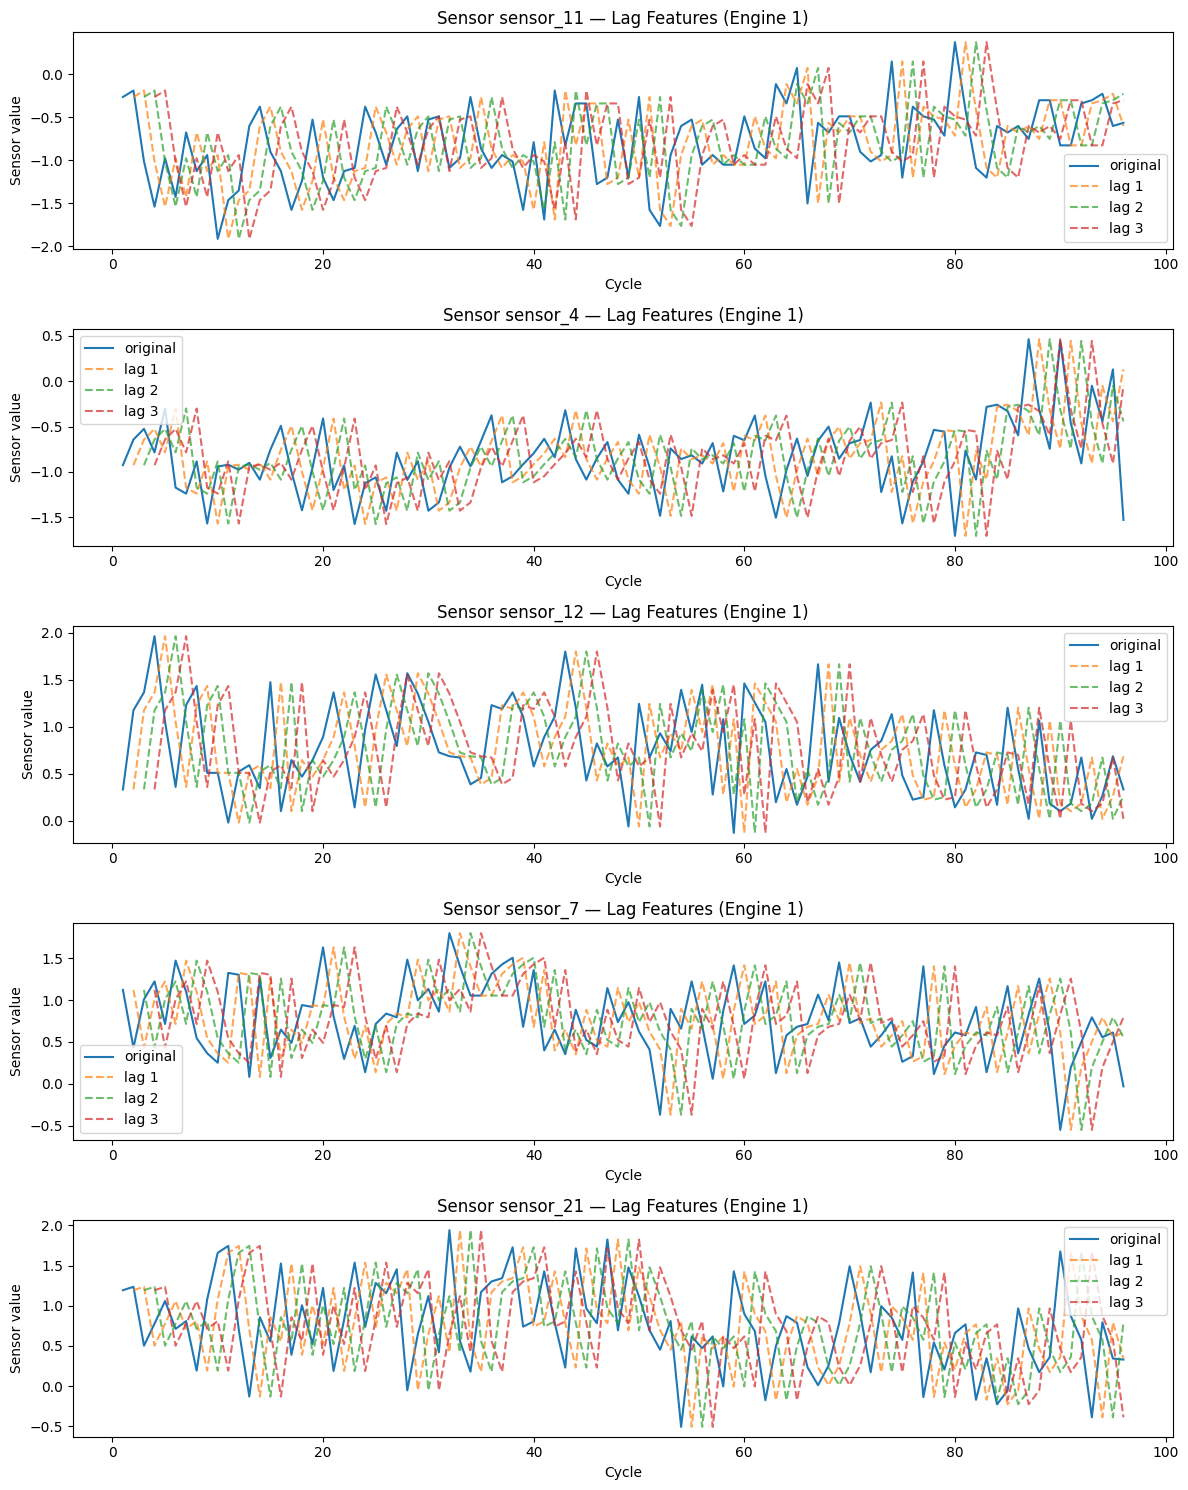

In [20]:
engine = 1
subset = df[df["engine_id"] == engine]
subset = subset[subset["cycle"] <= subset["cycle"].max() * 0.5]
lag_steps = [1, 2, 3]

fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(12, 3 * len(selected_sensors)))

for i, sensor in enumerate(selected_sensors):
    ax = axes[i]
    ax.plot(subset["cycle"],
            subset[sensor],
            label="original")

    for lag in lag_steps:
        ax.plot(subset["cycle"],
                subset[f"{sensor}_lag_{lag}"],
                label=f"lag {lag}",
                alpha=0.7,
                linestyle="--")

    ax.set_title(f"Sensor {sensor} — Lag Features (Engine {engine})")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Sensor value")
    ax.legend()

plt.tight_layout()
plt.show()

The plot shows the first 50% of Engine 1's operational life, where the shift
between the original signal and its lagged versions is clearly visible.

Each lag introduces a 1-cycle delay, effectively giving the model a short
temporal window into the sensor's recent past.

## Final feature selection

At this stage the dataset contains the original sensors, rolling statistics
and lag features.

We now consolidate the final feature set by retaining only
the columns that carry meaningful predictive information.

**Retained features:**
- `engine_id`, `cycle` — identifiers
- `RUL` — target variable
- top 5 sensors — original standardized values
- rolling mean and std (window=5) — trend and local volatility
- lag 1, 2, 3 — recent temporal history

In [21]:
identifier_cols = ["engine_id", "cycle"]
target_col = ["RUL"]

In [22]:
df_final = build_final_dataset(df, identifier_cols, target_col, selected_sensors)

In [23]:
print(f"Final dataset shape: {df_final.shape}")
print(f"Features: {df_final.shape[1] - len(identifier_cols) - len(target_col)}")
print(f"Missing values: {df_final.isnull().sum().sum()}")

Final dataset shape: (20231, 33)
Features: 30
Missing values: 0


In [24]:
df_final.head()

,engine_id,cycle,RUL,sensor_11,sensor_4,sensor_12,sensor_7,sensor_21,sensor_11_rolling_mean,sensor_11_rolling_std,...,sensor_4_lag_3,sensor_12_lag_1,sensor_12_lag_2,sensor_12_lag_3,sensor_7_lag_1,sensor_7_lag_2,sensor_7_lag_3,sensor_21_lag_1,sensor_21_lag_2,sensor_21_lag_3
4,1,5,187,-0.977861,-0.301518,1.052871,0.714393,1.059552,-0.798141,0.565607,...,-0.643726,1.961302,1.364721,1.174899,1.222827,1.008155,0.431930,0.777792,0.503423,1.236922
5,1,6,186,-1.427163,-1.173703,0.361379,1.471395,0.713126,-1.030280,0.529904,...,-0.525953,1.052871,1.961302,1.364721,0.714393,1.222827,1.008155,1.059552,0.777792,0.503423
6,1,7,185,-0.678327,-1.240367,1.229134,1.098544,0.810125,-1.127629,0.352232,...,-0.784831,0.361379,1.052871,1.961302,1.471395,0.714393,1.222827,0.713126,1.059552,0.777792
7,1,8,184,-1.127629,-0.884827,1.432514,0.544915,0.193025,-1.150094,0.346817,...,-0.301518,1.229134,0.361379,1.052871,1.098544,1.471395,0.714393,0.810125,0.713126,1.059552
8,1,9,183,-0.940420,-1.570353,0.510525,0.364139,1.079876,-1.030280,0.274630,...,-1.173703,1.432514,1.229134,0.361379,0.544915,1.098544,1.471395,0.193025,0.810125,0.713126


NaN values introduced by rolling and lag operations are dropped.

The final dataset is clean and ready for the train-validation split.

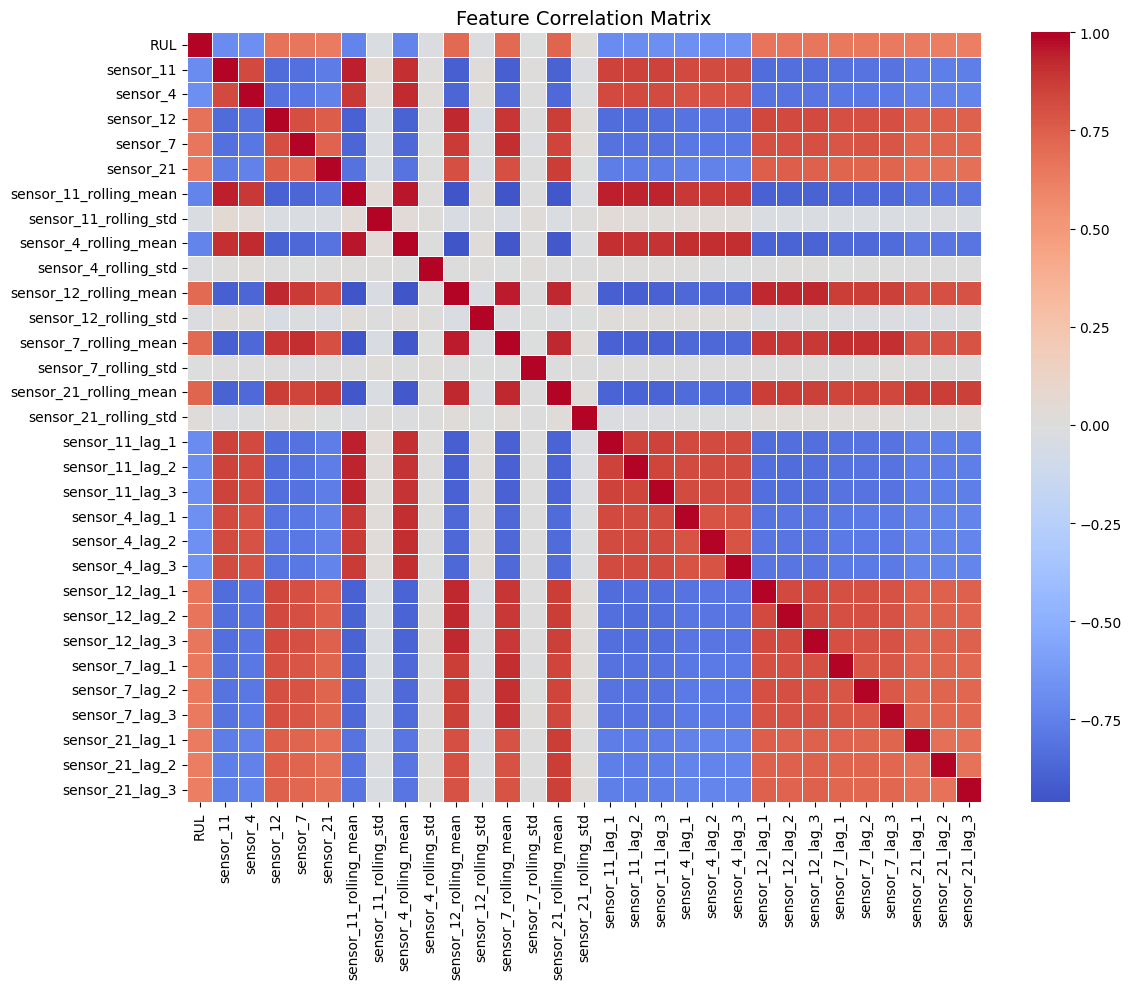

In [25]:
plt.figure(figsize=(12, 10))
corr_matrix = df_final.drop(columns=["engine_id", "cycle"]).corr()

sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            annot=False,
            linewidths=0.5)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

The heatmap reveals three distinct correlation blocks:
- **Original sensors + rolling mean**: highly correlated by construction
- **Rolling std**: largely decorrelated from all other features,
  capturing independent volatility information
- **Lag features**: strongly correlated with originals but decreasing
  with lag distance, confirming they encode recent temporal history

No perfectly redundant features are present — the final feature set
is validated and ready for modeling.

## Train-Validation split

The final dataset is split into three distinct sets, each designed
for a specific downstream task:

- **RUL Forecasting**: 80/20 split by `engine_id` — engines are independent units
- **Forecasting**: 80/20 temporal split per engine — predict future sensor values
- **Anomaly Detection**: healthy vs degraded split — train on early cycles only,
  test on degraded behavior (RUL < threshold)

In [26]:
splits = split_datasets(df_final, rul_threshold=125, temporal_ratio=0.8, random_seed=42)

### RUL Forecasting — split by engine_id

In [27]:
df_rul_train, df_rul_val = splits["rul"]
print(f"RUL Forecasting  — train: {df_rul_train.shape}, val: {df_rul_val.shape}")

RUL Forecasting  — train: (16020, 33), val: (4211, 33)


### Sensor Forecasting — temporal split per engine

In [28]:
df_forecast_train, df_forecast_val = splits["forecast"]
print(f"Sensor Forecasting — train: {df_forecast_train.shape}, val: {df_forecast_val.shape}")

Sensor Forecasting — train: (16145, 33), val: (4086, 33)


### Anomaly Detection — healthy vs degraded

In [29]:
df_anomaly_train, df_anomaly_val = splits["anomaly"]
print(f"Anomaly Detection — healthy: {df_anomaly_train.shape}, degraded: {df_anomaly_val.shape}")

Anomaly Detection — healthy: (7732, 33), degraded: (12499, 33)


The RUL threshold for anomaly detection (125 cycles) is a conservative estimate based on the average engine lifetime in FD001 (~200 cycles).

This value will be revisited during the anomaly detection modeling phase.

The healthy/degraded split is imbalanced (7732 vs 12499 samples).

Class imbalance will be addressed during the anomaly detection modeling phase via resampling or threshold tuning.

## Save processed datasets

In [30]:
# RUL Forecasting
df_rul_train.to_parquet("../data/processed/rul_train.parquet", index=False)
df_rul_val.to_parquet("../data/processed/rul_val.parquet", index=False)

# Sensor Forecasting
df_forecast_train.to_parquet("../data/processed/forecast_train.parquet", index=False)
df_forecast_val.to_parquet("../data/processed/forecast_val.parquet", index=False)

# Anomaly Detection
df_anomaly_train.to_parquet("../data/processed/anomaly_healthy.parquet", index=False)
df_anomaly_val.to_parquet("../data/processed/anomaly_degraded.parquet", index=False)

In [31]:
print("Saved files:")
for f in os.listdir("../data/processed/"):
    print(f"  {f}")

Saved files:
  rul_train.parquet
  anomaly_healthy.parquet
  anomaly_degraded.parquet
  forecast_val.parquet
  rul_val.parquet
  forecast_train.parquet


## Summary

| Step | Input | Output |
|------|-------|--------|
| Sensor selection | 21 sensors | 11 sensors (10 dropped) |
| Normalization | raw values | zero mean, unit variance |
| Rolling features | 5 sensors | +10 features |
| Lag features | 5 sensors | +15 features |
| Final selection | 29 cols | 33 cols (30 features) |
| Split | 20231 rows | 3 task-specific datasets |